# 03 — Analysis & Figures

Produces the six figures from the aggregated monthly data and (where noted) the full
preprocessed corpus.

- **Figure 1** — Monthly coverage volume (RQ1), with DOC API cross-validation overlay
- **Figure 2** — Frame distribution over time (RQ2)
- **Figure 3** — Event study across all 7 governance milestones (RQ3)
- **Figure 4** (optional) — Regional comparison — requires the full raw corpus
- **Figures 5–6** (optional) — Tone over time / tone by frame — requires the full raw corpus

Figures are saved to `../paper/figures/`, overwriting any previous run's output.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path('..')))

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from src.analysis import (
    load_agg,
    monthly_volume_agg, frame_shares_agg, event_study_agg,
)
from src.doc_api import fetch_timeline_vol, build_doc_query
from src.dictionaries import MILESTONES

FIGURES = Path('../paper/figures')
FIGURES.mkdir(parents=True, exist_ok=True)

sns.set_theme(style='whitegrid', palette='colorblind')
MILESTONE_DATES = {m['name']: pd.Timestamp(m['date']) for m in MILESTONES}

In [2]:
agg_df = load_agg('../data/processed/monthly_frames.csv')
print(f'{len(agg_df)} months, {agg_df["total_articles"].sum():,} total articles')

44 months, 1,104,618 total articles


In [3]:
_RAW_PROCESSED = Path('../data/interim/gdelt_preprocessed.parquet')

# Basic statistics from the aggregated CSV
_vol = monthly_volume_agg(agg_df)
print(f"Date range:       {agg_df['month'].min()} – {agg_df['month'].max()}")
print(f"Months:           {len(agg_df)}")
print(f"Total articles:   {agg_df['total_articles'].sum():,}")
print(f"Mean/month:       {agg_df['total_articles'].mean():,.0f}")
print(f"Min/month:        {agg_df['total_articles'].min():,}  ({agg_df.loc[agg_df['total_articles'].idxmin(), 'month']})")
print(f"Max/month:        {agg_df['total_articles'].max():,}  ({agg_df.loc[agg_df['total_articles'].idxmax(), 'month']})")
print()

_frame_totals = agg_df[[c for c in agg_df.columns if c.startswith('frame_')]].sum()
_frame_share = _frame_totals / _frame_totals.sum()
print("Frame keyword hit distribution (% of all hits across corpus):")
for col, share in _frame_share.items():
    print(f"  {col.replace('frame_', ''):<38} {share:.1%}")

# Extended stats from per-article parquet (if available)
print()
if _RAW_PROCESSED.exists():
    from src.analysis import frame_coverage_rate
    _df_tmp = pd.read_parquet(_RAW_PROCESSED)
    _fcr = frame_coverage_rate(_df_tmp)
    print(f"Frame coverage (from parquet, n={_fcr['total']:,}):")
    print(f"  Articles with any frame hit:  {_fcr['any_frame_pct']:.1%}")
    print(f"  Articles with zero frame hit: {_fcr['zero_frame_pct']:.1%}")
    print(f"  Articles with 2+ frame hits:  {_fcr['multi_frame_pct']:.1%}")
    del _df_tmp
else:
    print("(Frame coverage rate requires data/interim/gdelt_preprocessed.parquet)")

Date range:       2022-11 – 2026-06
Months:           44
Total articles:   1,104,618
Mean/month:       25,105
Min/month:        12,986  (2025-06)
Max/month:        31,120  (2025-03)

Frame keyword hit distribution (% of all hits across corpus):
  innovation_opportunity                 16.8%
  risk_safety                            18.1%
  regulation_governance                  40.2%
  rights_privacy                         4.6%
  economic_competition_labour            17.4%
  misinformation_integrity               3.0%

Frame coverage (from parquet, n=1,103,744):
  Articles with any frame hit:  57.8%
  Articles with zero frame hit: 42.2%
  Articles with 2+ frame hits:  23.6%


## Figure 1 — Monthly coverage volume (RQ1)

Grounded in Fast & Horvitz (2017)'s longitudinal NYT AI-coverage volume analysis and
Chuan et al. (2019)'s finding that AI news coverage is dominated by business/economy
framing — both precedents for treating raw volume-over-time as a meaningful RQ1 signal.

In [5]:
# Fetch DOC API cross-validation data — run once; result cached in vol_api / has_api
try:
    vol_api = fetch_timeline_vol(build_doc_query(), start='20221101000000', end='20260601000000')
    has_api = True
    print(f"DOC API: {len(vol_api)} months fetched")
except Exception as e:
    print(f'DOC API unavailable ({e}), skipping overlay')
    vol_api = None
    has_api = False

Rate limited (429); retrying in 10s …
Rate limited (429); retrying in 20s …
DOC API: 44 months fetched


/home/Brewen/cwd/tud/GenAI-GDELT/notebooks/../src/doc_api.py:118: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df["month"] = df["date"].dt.to_period("M")


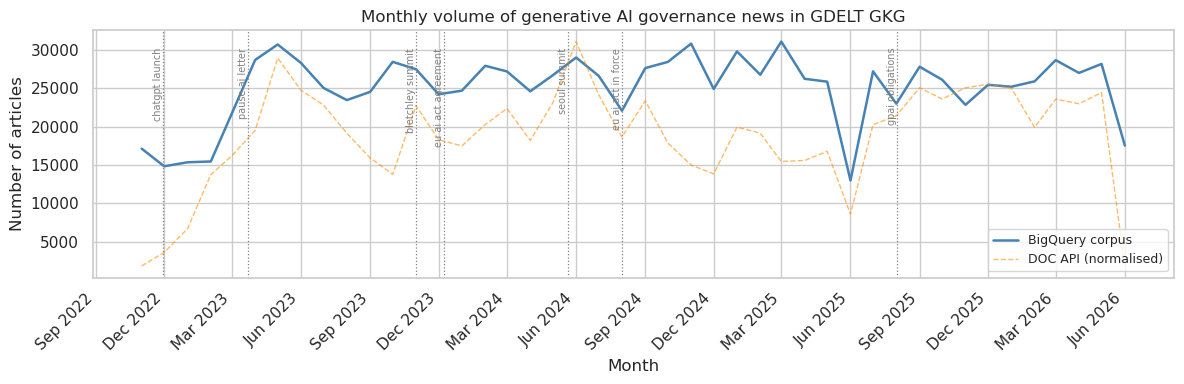

Saved fig1_monthly_volume.png


In [6]:
vol = monthly_volume_agg(agg_df)
vol_dates = vol.index.to_timestamp()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(vol_dates, vol.values, linewidth=1.8, label='BigQuery corpus', color='steelblue')
if has_api and vol_api is not None:
    api_dates = vol_api['month'].dt.to_timestamp()
    api_scaled = vol_api['volume'] / vol_api['volume'].max() * vol.max()
    ax.plot(api_dates, api_scaled, linewidth=1, linestyle='--',
            alpha=0.6, label='DOC API (normalised)', color='darkorange')

for name, ts in MILESTONE_DATES.items():
    ax.axvline(ts, color='grey', linestyle=':', linewidth=0.9)
    ax.text(ts, ax.get_ylim()[1] * 0.93, name.replace('_', ' '),
            rotation=90, fontsize=7, ha='right', va='top', color='grey')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45, ha='right')
ax.set_xlabel('Month')
ax.set_ylabel('Number of articles')
ax.set_title('Monthly volume of generative AI governance news in GDELT GKG')
if has_api:
    ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(FIGURES / 'fig1_monthly_volume.png', bbox_inches='tight')
plt.show()
print('Saved fig1_monthly_volume.png')

## Figure 2 — Frame distribution over time (RQ2)

Grounded in Hendrickx & Van Coppenolle (2026), the most directly comparable prior study:
both find coverage broadening from a "tool"/innovation frame toward regulatory/societal
framing over time. Nguyen & Wischnewski (2026) (anthropomorphic/agentic framing) and Lee
& Park (2026) (impact/responsibility attribution) study related but different framing
dimensions this analysis does not measure — noted here as explicit scope boundaries, not
results to compare against.

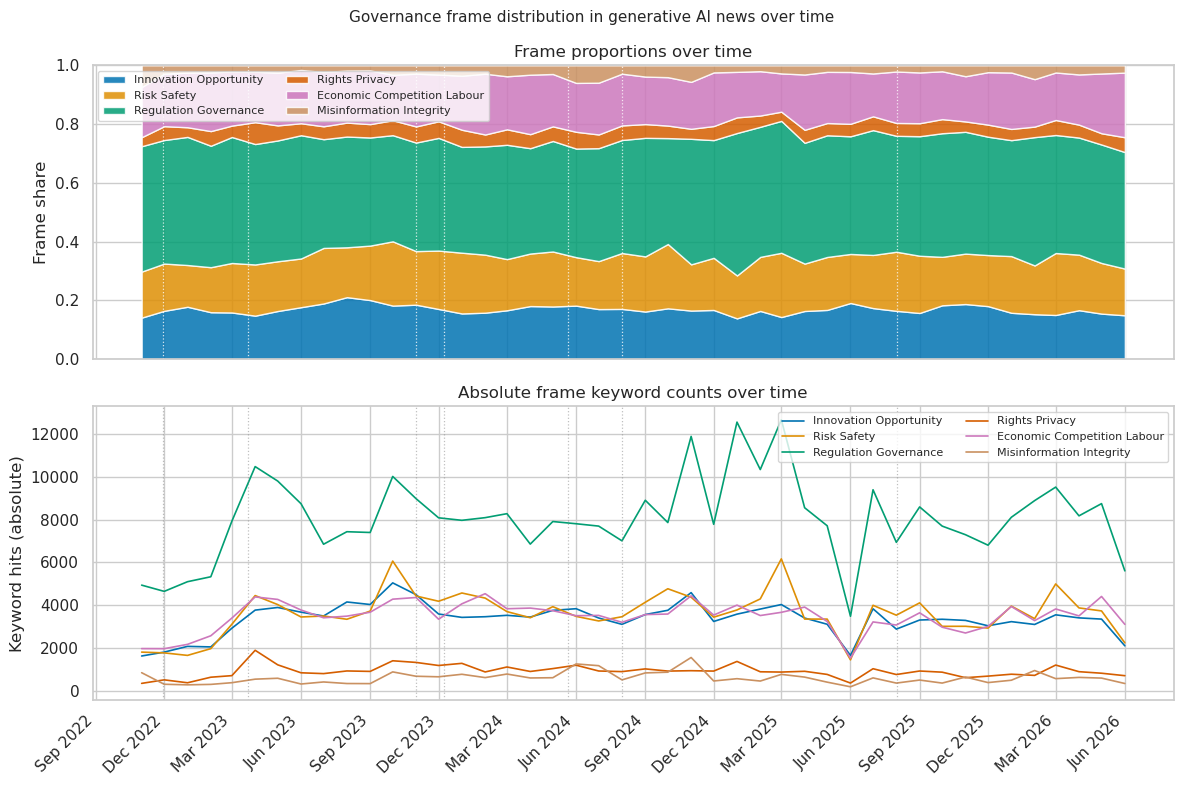

Saved fig2_frame_shares.png


In [7]:
from src.analysis import frame_counts_agg

counts = frame_counts_agg(agg_df)
counts_dates = counts.index.to_timestamp()
shares = frame_shares_agg(agg_df)
shares_dates = shares.index.to_timestamp()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Panel 1: frame shares (stacked area)
ax1.stackplot(
    shares_dates,
    [shares[col] for col in shares.columns],
    labels=[c.replace('_', ' ').title() for c in shares.columns],
    alpha=0.85,
)
for name, ts in MILESTONE_DATES.items():
    ax1.axvline(ts, color='white', linestyle=':', linewidth=0.9, alpha=0.8)
ax1.set_ylabel('Frame share')
ax1.set_ylim(0, 1)
ax1.set_title('Frame proportions over time')
ax1.legend(loc='upper left', fontsize=8, ncol=2)

# Panel 2: absolute keyword hit counts per frame
for col in counts.columns:
    ax2.plot(counts_dates, counts[col], linewidth=1.2,
             label=col.replace('_', ' ').title())
for name, ts in MILESTONE_DATES.items():
    ax2.axvline(ts, color='grey', linestyle=':', linewidth=0.9, alpha=0.5)
ax2.set_ylabel('Keyword hits (absolute)')
ax2.set_title('Absolute frame keyword counts over time')
ax2.legend(fontsize=8, ncol=2)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45, ha='right')

fig.suptitle('Governance frame distribution in generative AI news over time', fontsize=11)
plt.tight_layout()
plt.savefig(FIGURES / 'fig2_frame_shares.png', bbox_inches='tight')
plt.show()
print('Saved fig2_frame_shares.png')

## Figure 3 — Event study: all milestones (RQ3)

Compares coverage volume and frame distribution in a ±3-month window around each of the
7 governance milestones in `MILESTONES` (see `MERGE_PLAN.md` for the full list and the
documented window-overlap caveat for the 2023–2024 cluster).

Grounded in Cheung (2025) (UK policy shift after "AI crisis" framing — motivates the
Bletchley test), Gstrein et al. (2024) (EU AI Act as a shift from reactive to proactive
governance — motivates testing the agreement/in-force date pair as a contrast), and
Taeihagh (2025) (governance challenges spanning data governance/IP/bias/misinformation —
maps onto the six frames tested here).

In [8]:
milestone_results = {}
for m in MILESTONES:
    try:
        res = event_study_agg(agg_df, m['name'])
        milestone_results[m['name']] = res
        peak = res['volume'].idxmax()
        print(f"{m['name']:<20}  peak rel_month={peak:+d}  count={res['volume'].max():,}")
    except ValueError as e:
        print(f"Skipping {m['name']}: {e}")

chatgpt_launch        peak rel_month=+0  count=17,143
pause_ai_letter       peak rel_month=+2  count=30,738
bletchley_summit      peak rel_month=-1  count=28,474
eu_ai_act_agreement   peak rel_month=-2  count=28,474
seoul_summit          peak rel_month=+1  count=29,038
eu_ai_act_in_force    peak rel_month=+3  count=30,851
gpai_obligations      peak rel_month=+1  count=27,838


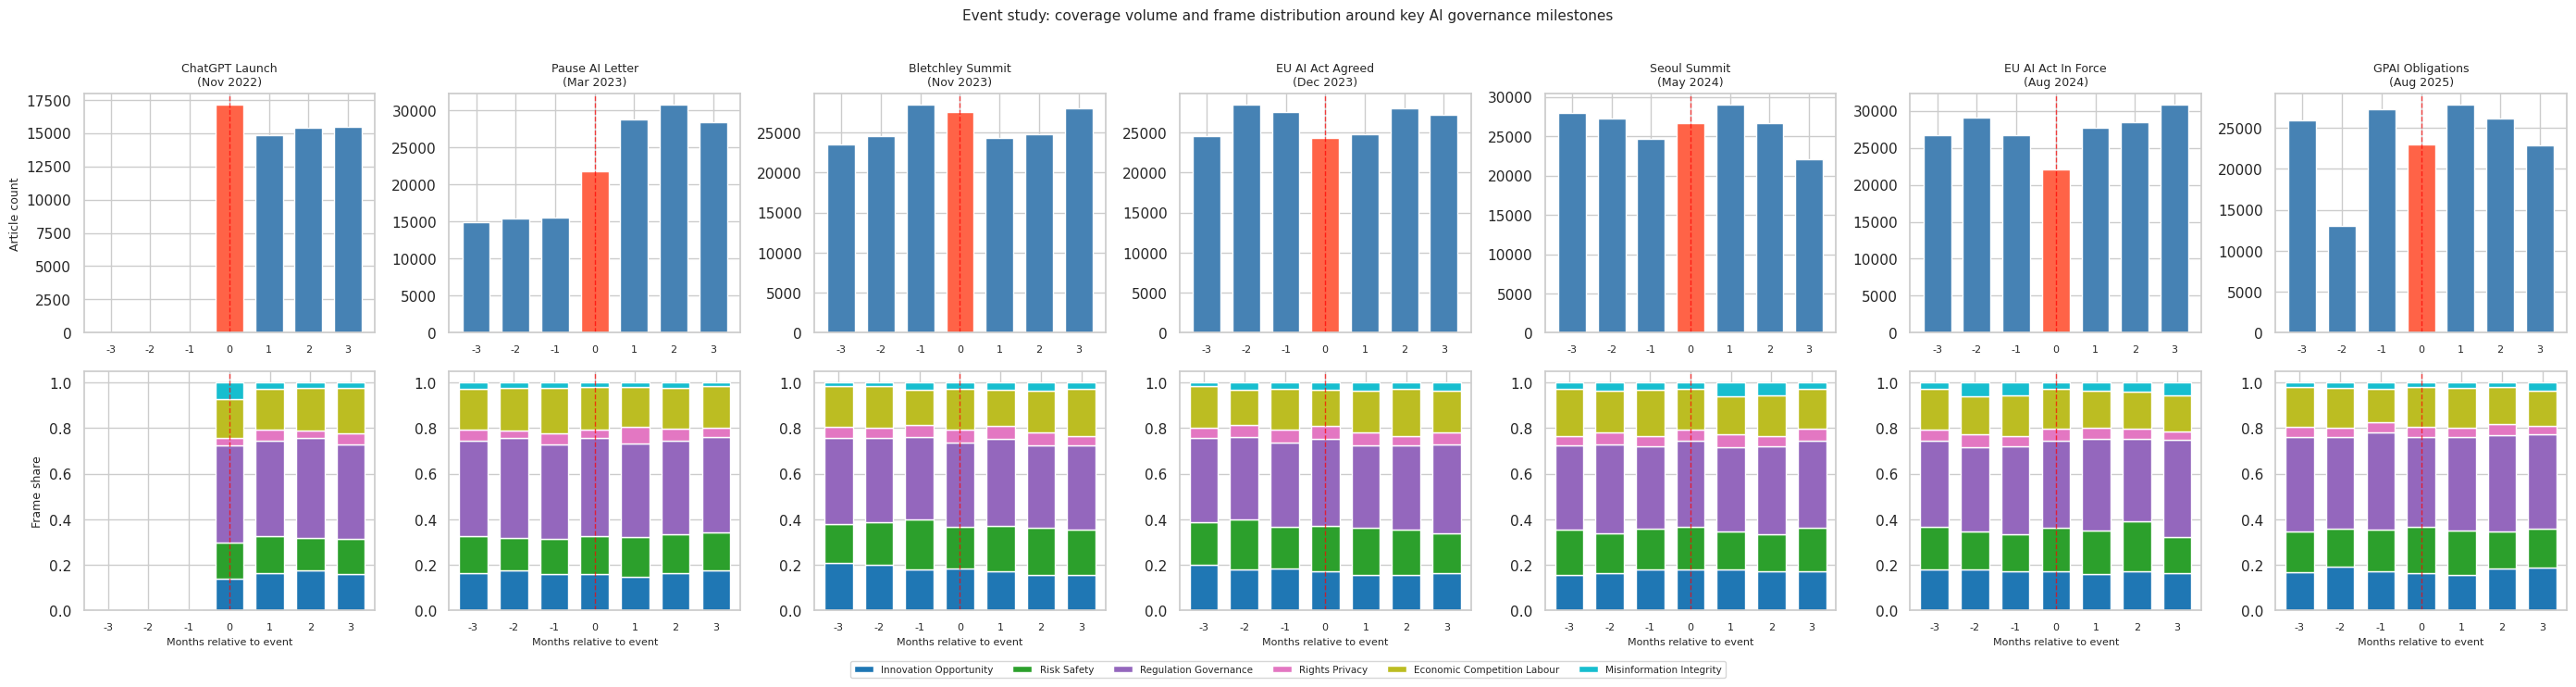

Saved fig3_event_study_all.png


In [9]:
_milestone_labels = {
    'chatgpt_launch':      'ChatGPT Launch\n(Nov 2022)',
    'pause_ai_letter':     'Pause AI Letter\n(Mar 2023)',
    'bletchley_summit':    'Bletchley Summit\n(Nov 2023)',
    'eu_ai_act_agreement': 'EU AI Act Agreed\n(Dec 2023)',
    'seoul_summit':        'Seoul Summit\n(May 2024)',
    'eu_ai_act_in_force':  'EU AI Act In Force\n(Aug 2024)',
    'gpai_obligations':    'GPAI Obligations\n(Aug 2025)',
}

# Grid columns derive from len(MILESTONES) rather than a hardcoded count, so adding or
# removing milestones in src/dictionaries.py doesn't silently truncate this figure.
n_milestones = len(MILESTONES)
fig, axes = plt.subplots(2, n_milestones, figsize=(4 * n_milestones, 7))

for col_idx, m in enumerate(MILESTONES):
    name = m['name']
    if name not in milestone_results:
        for row in range(2):
            axes[row, col_idx].set_visible(False)
        continue

    res = milestone_results[name]
    vol_es = res['volume']
    shares_es = res['shares']
    label = _milestone_labels.get(name, name.replace('_', ' ').title())

    # Row 0: volume bar chart
    ax_v = axes[0, col_idx]
    bar_colors = ['tomato' if i == 0 else 'steelblue' for i in vol_es.index]
    ax_v.bar(vol_es.index, vol_es.values, color=bar_colors, width=0.7)
    ax_v.axvline(0, color='red', linestyle='--', linewidth=1.0, alpha=0.7)
    ax_v.set_xticks(range(-3, 4))
    ax_v.set_xticklabels(range(-3, 4), fontsize=8)
    ax_v.set_title(label, fontsize=9)
    if col_idx == 0:
        ax_v.set_ylabel('Article count', fontsize=9)

    # Row 1: frame shares stacked bar chart
    ax_f = axes[1, col_idx]
    shares_es.plot(kind='bar', stacked=True, ax=ax_f, legend=False,
                   colormap='tab10', width=0.7, rot=0)
    ax_f.axvline(3, color='red', linestyle='--', linewidth=1.0, alpha=0.7)
    ax_f.set_xticklabels([str(i) for i in range(-3, 4)], fontsize=8)
    ax_f.set_xlabel('Months relative to event', fontsize=8)
    if col_idx == 0:
        ax_f.set_ylabel('Frame share', fontsize=9)

# Shared legend for frames (below the figure)
handles, frame_labels = axes[1, 0].get_legend_handles_labels()
fig.legend(handles, [l.replace('_', ' ').title() for l in frame_labels],
           loc='lower center', ncol=6, fontsize=7.5, bbox_to_anchor=(0.5, -0.03))

fig.suptitle(
    'Event study: coverage volume and frame distribution around key AI governance milestones',
    fontsize=11, y=1.01,
)
plt.tight_layout()
plt.savefig(FIGURES / 'fig3_event_study_all.png', bbox_inches='tight')
plt.show()
print('Saved fig3_event_study_all.png')

## Figure 4 (optional) — Regional comparison

Requires the full raw corpus (`data/interim/gdelt_preprocessed.parquet`) from notebook 02 Part B.
Skip if you only ran the aggregated path.

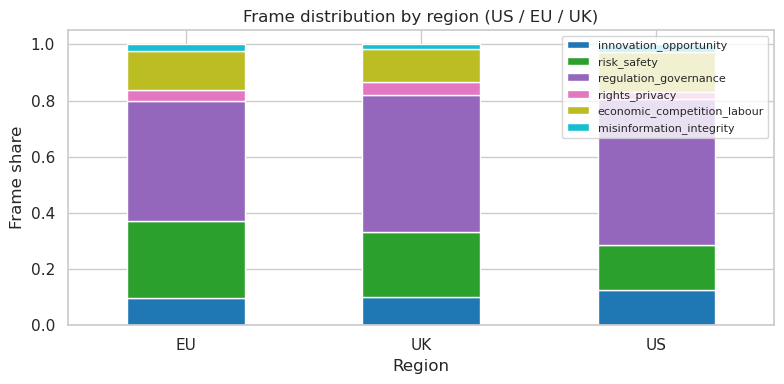

Saved fig4_regional_comparison.png


In [10]:
RAW_PROCESSED = Path('../data/interim/gdelt_preprocessed.parquet')
if not RAW_PROCESSED.exists():
    print('Preprocessed raw corpus not found — skipping regional comparison.')
else:
    from src.analysis import region_comparison

    df_raw = pd.read_parquet(RAW_PROCESSED)
    reg = region_comparison(df_raw)

    fig, ax = plt.subplots(figsize=(8, 4))
    reg.plot(kind='bar', stacked=True, ax=ax, colormap='tab10')
    ax.set_xlabel('Region')
    ax.set_ylabel('Frame share')
    ax.set_title('Frame distribution by region (US / EU / UK)')
    ax.legend(fontsize=8, loc='upper right')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.savefig(FIGURES / 'fig4_regional_comparison.png', bbox_inches='tight')
    plt.show()
    print('Saved fig4_regional_comparison.png')

## Supplementary figures (require full preprocessed corpus)

The cells below require `data/interim/gdelt_preprocessed.parquet` (produced by notebook 02 Part B).
They are gated and will print a skip message if the file is absent.

- **Figure 5** — Mean article tone over time
- **Figure 6** — Tone score distribution by dominant frame
- **Source concentration** — Top-20 sources + HHI (for limitations section)

Tone analysis (Figures 5–6) is grounded in Eisenbeis & Elkins (2024), which analyzes AI
sentiment trends in US news reporting.

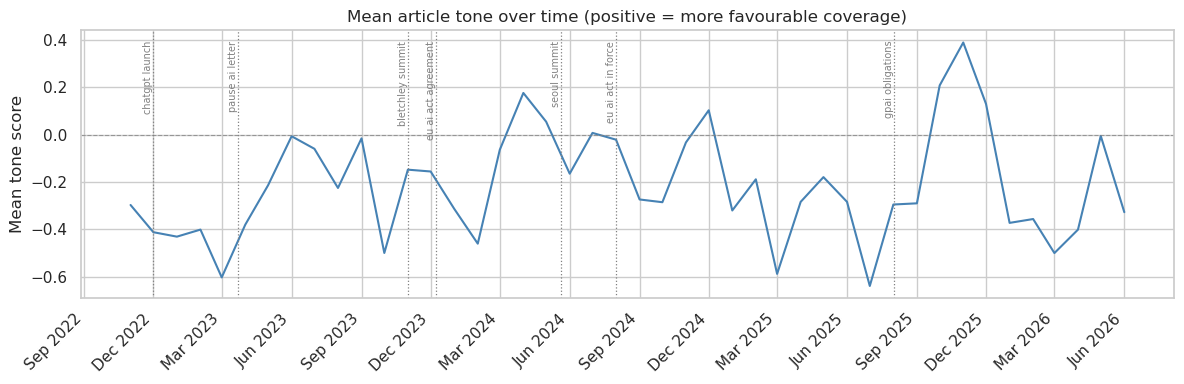

Saved fig5_tone_over_time.png


In [11]:
_RAW_PROCESSED = Path('../data/interim/gdelt_preprocessed.parquet')
if not _RAW_PROCESSED.exists():
    print('Preprocessed corpus not found — skipping tone over time.')
else:
    from src.analysis import tone_over_time
    try:
        df_raw
    except NameError:
        df_raw = pd.read_parquet(_RAW_PROCESSED)

    tone_monthly = tone_over_time(df_raw)
    tone_dates = tone_monthly.index.to_timestamp()

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(tone_dates, tone_monthly.values, linewidth=1.5, color='steelblue')
    ax.axhline(0, color='grey', linestyle='--', linewidth=0.8, alpha=0.7)
    for name, ts in MILESTONE_DATES.items():
        ax.axvline(ts, color='grey', linestyle=':', linewidth=0.9)
        ax.text(ts, ax.get_ylim()[1] * 0.9, name.replace('_', ' '),
                rotation=90, fontsize=7, ha='right', va='top', color='grey')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.xticks(rotation=45, ha='right')
    ax.set_ylabel('Mean tone score')
    ax.set_title('Mean article tone over time (positive = more favourable coverage)')
    plt.tight_layout()
    plt.savefig(FIGURES / 'fig5_tone_over_time.png', bbox_inches='tight')
    plt.show()
    print('Saved fig5_tone_over_time.png')

/tmp/ipykernel_27271/3547581321.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


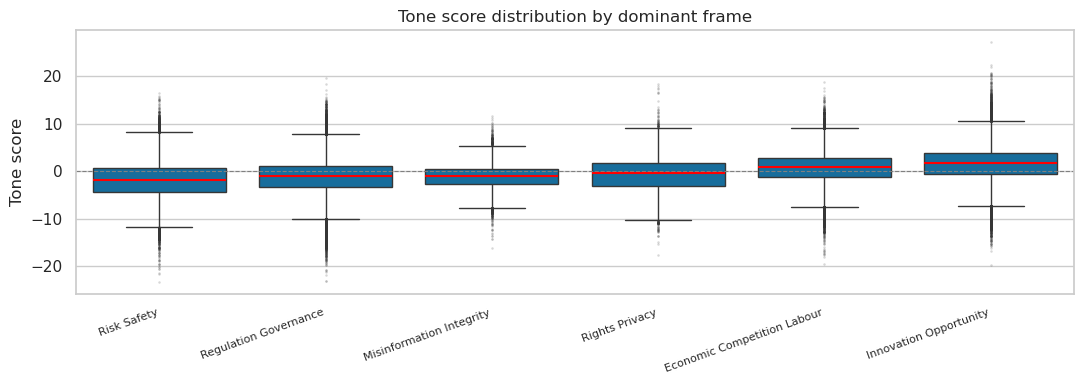

Saved fig6_tone_by_frame.png

Source HHI: 0.0012  (0 = perfectly equal, 1 = monopoly)

Top 20 sources by article count:
  zazoom.it                                       18,358  (1.7%)
  yahoo.com                                       16,838  (1.5%)
  iheart.com                                      12,723  (1.2%)
  indiatimes.com                                   6,466  (0.6%)
  varesenews.it                                    5,560  (0.5%)
  ansa.it                                          5,019  (0.5%)
  ilgiorno.it                                      4,739  (0.4%)
  finanznachrichten.de                             4,129  (0.4%)
  boursier.com                                     4,012  (0.4%)
  kompas.com                                       3,883  (0.4%)
  pikiran-rakyat.com                               3,784  (0.3%)
  sohu.com                                         3,467  (0.3%)
  forbes.com                                       3,413  (0.3%)
  marketscreener.com               

In [12]:
_RAW_PROCESSED = Path('../data/interim/gdelt_preprocessed.parquet')
if not _RAW_PROCESSED.exists():
    print('Preprocessed corpus not found — skipping tone by frame and source concentration.')
else:
    from src.analysis import source_concentration
    try:
        df_raw
    except NameError:
        df_raw = pd.read_parquet(_RAW_PROCESSED)

    # --- Tone by dominant frame ---
    df_tone = df_raw[df_raw['dominant_frame'].notna()].copy()
    frame_order = (
        df_tone.groupby('dominant_frame')['tone'].median()
        .sort_values().index.tolist()
    )
    fig, ax = plt.subplots(figsize=(11, 4))
    sns.boxplot(
        data=df_tone, x='dominant_frame', y='tone', order=frame_order, ax=ax,
        flierprops=dict(marker='.', markersize=1.5, alpha=0.2),
        medianprops=dict(color='red', linewidth=1.5),
    )
    ax.axhline(0, color='grey', linestyle='--', linewidth=0.8)
    ax.set_title('Tone score distribution by dominant frame')
    ax.set_xlabel('')
    ax.set_xticklabels(
        [l.replace('_', ' ').title() for l in frame_order],
        rotation=20, ha='right', fontsize=8,
    )
    ax.set_ylabel('Tone score')
    plt.tight_layout()
    plt.savefig(FIGURES / 'fig6_tone_by_frame.png', bbox_inches='tight')
    plt.show()
    print('Saved fig6_tone_by_frame.png')

    # --- Source concentration ---
    print()
    top_sources, hhi = source_concentration(df_raw)
    print(f'Source HHI: {hhi:.4f}  (0 = perfectly equal, 1 = monopoly)')
    print(f'\nTop 20 sources by article count:')
    for src, cnt in top_sources.items():
        pct = cnt / len(df_raw) * 100
        print(f'  {str(src):<45}  {cnt:>7,}  ({pct:.1f}%)')